# EDA Notebook 

## Purpose

This notebook supports and defends the final feature strategy for the AQI forecasting project.

The project uses:

- Raw Open-Meteo air-quality features
- Raw Open-Meteo weather features
- 19 derived model features
- Open-Meteo `us_aqi` as the target

The model learns:

```text
Open-Meteo AQI(t) = f(derived pollutant-window features at time t + weather features at time t)
```

The goal of this EDA is to prove that the chosen features are meaningful, forecast-safe, and strongly related to AQI.


## Why Unit Conversion Is Needed

Open-Meteo provides gaseous pollutant concentrations in `µg/m³`.

For more interpretable gas features:

- Ozone is converted to `ppb`
- Nitrogen dioxide is converted to `ppb`
- Carbon monoxide is converted to `ppm`

The conversion formula is:

```text
ppb = (µg/m³ × 24.465) / molecular_weight
ppm = ppb / 1000
```

So in the project:

```python
o3_8h_ppb  = o3_8h * (24.465 / 48)
no2_1h_ppb = no2_1h * (24.465 / 46)
co_8h_ppm  = co_8h * (24.465 / (28 * 1000))
```

Where approximate molecular weights are:

| Gas | Molecular weight |
|---|---:|
| O3 | 48 |
| NO2 | 46 |
| CO | 28 |

This conversion makes gas features easier to interpret and aligns them with common air-quality concentration units.


In [1]:
# ============================================================
# Imports and setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"D:\aqi-predictor")
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
EDA_DIR = REPORTS_DIR / "eda"
FIGURES_DIR = REPORTS_DIR / "figures"

EDA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CACHE_PATH = DATA_DIR / "openmeteo_12f_training_cache.pkl"
CSV_PATH = DATA_DIR / "openmeteo_12f_training_features.csv"

TARGET_COL = "us_aqi"

RAW_AIR_QUALITY_COLS = [
    "pm25",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "ozone",
]

RAW_WEATHER_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "windspeed_10m",
    "surface_pressure",
    "shortwave_radiation",
    "et0_fao_evapotranspiration",
]

FEATURE_COLS = [
    "pm25_24h",
    "pm10_24h",
    "o3_8h_ppb",
    "co_8h_ppm",
    "no2_1h_ppb",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "windspeed_10m",
    "surface_pressure",
    "shortwave_radiation",
    "et0_fao_evapotranspiration",
]

DERIVED_POLLUTANT_COLS = [
    "pm25_24h",
    "pm10_24h",
    "o3_8h_ppb",
    "co_8h_ppm",
    "no2_1h_ppb",
]

print("Project root:", PROJECT_ROOT)
print("EDA output:", EDA_DIR)
print("Figures output:", FIGURES_DIR)


Project root: D:\aqi-predictor
EDA output: D:\aqi-predictor\reports\eda
Figures output: D:\aqi-predictor\reports\figures


In [2]:
# ============================================================
# Load training data
# ============================================================

if CACHE_PATH.exists():
    df = pd.read_pickle(CACHE_PATH)
    print(f"Loaded cache: {CACHE_PATH}")
elif CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded CSV: {CSV_PATH}")
else:
    raise FileNotFoundError(
        "Training data not found. Run backfill first:\n"
        "python pipelines/backfill_pipeline.py --no-upload"
    )

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())


Loaded cache: D:\aqi-predictor\data\openmeteo_12f_training_cache.pkl
Shape: (4320, 31)


,city,timestamp,ingestion_timestamp,pm25,pm10,carbon_monoxide,nitrogen_dioxide,ozone,temperature_2m,relative_humidity_2m,...,co_8h_ppm,no2_1h_ppb,hour,day_of_week,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,us_aqi
0,hyderabad,2025-12-01 00:00:00,2026-05-30 12:52:33.558840,70.3,71.2,1323.0,41.3,38.0,16.8,50,...,1.155971,21.965315,0,0,0,0.000000,1.000000,0.0,1.0,116
1,hyderabad,2025-12-01 01:00:00,2026-05-30 12:52:33.558840,72.4,73.6,1195.0,41.4,34.0,16.0,53,...,1.100051,22.018500,1,0,0,0.258819,0.965926,0.0,1.0,118
2,hyderabad,2025-12-01 02:00:00,2026-05-30 12:52:33.558840,73.6,74.7,1060.0,40.5,31.0,14.6,58,...,1.042093,21.539837,2,0,0,0.500000,0.866025,0.0,1.0,122
3,hyderabad,2025-12-01 03:00:00,2026-05-30 12:52:33.558840,73.3,74.3,838.0,37.7,29.0,13.8,63,...,0.964620,20.050663,3,0,0,0.707107,0.707107,0.0,1.0,125
4,hyderabad,2025-12-01 04:00:00,2026-05-30 12:52:33.558840,71.2,72.2,609.0,33.9,29.0,13.1,65,...,0.878119,18.029641,4,0,0,0.866025,0.500000,0.0,1.0,129


## 1. Dataset Overview

This section checks the dataset size, date range, and whether the 6-month backfill produced enough hourly rows for training.


In [3]:
overview = {
    "rows": len(df),
    "columns": df.shape[1],
    "start_time": df["timestamp"].min(),
    "end_time": df["timestamp"].max(),
    "total_days": (df["timestamp"].max() - df["timestamp"].min()).days + 1,
    "target_min": df[TARGET_COL].min(),
    "target_mean": df[TARGET_COL].mean(),
    "target_max": df[TARGET_COL].max(),
}

overview_df = pd.DataFrame([overview])
overview_df.to_csv(EDA_DIR / "dataset_overview.csv", index=False)

display(overview_df)

print(
    f"Dataset covers {overview['total_days']} days from "
    f"{overview['start_time']} to {overview['end_time']}."
)
print(
    f"AQI target range: {overview['target_min']:.2f} to {overview['target_max']:.2f}, "
    f"mean={overview['target_mean']:.2f}."
)


,rows,columns,start_time,end_time,total_days,target_min,target_mean,target_max
0,4320,31,2025-12-01,2026-05-29 23:00:00,180,28,91.435648,163


Dataset covers 180 days from 2025-12-01 00:00:00 to 2026-05-29 23:00:00.
AQI target range: 28.00 to 163.00, mean=91.44.


### Interpretation

A stable AQI model needs enough hourly data to learn pollution and weather patterns.  
A 6-month backfill usually gives thousands of hourly records, which is enough for a solid student/internship-level AQI forecasting model.


## 2. Data Quality Checks

We check:

- Missing values
- Duplicate timestamps
- Hourly gaps
- Numeric validity

This is important because rolling features and time-series splits depend on clean chronological data.


In [4]:
required_cols = [
    "timestamp",
    *RAW_AIR_QUALITY_COLS,
    *RAW_WEATHER_COLS,
    *FEATURE_COLS,
    TARGET_COL,
]

missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

missing_df = (
    df[required_cols]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing_df["missing_percent"] = missing_df["missing_count"] / len(df) * 100
missing_df.to_csv(EDA_DIR / "missing_values.csv", index=False)

duplicate_count = df.duplicated(subset=["city", "timestamp"]).sum() if "city" in df.columns else df.duplicated(subset=["timestamp"]).sum()

time_diff = df["timestamp"].diff()
gap_df = pd.DataFrame({
    "timestamp": df["timestamp"],
    "gap_from_previous": time_diff,
})
large_gaps = gap_df[gap_df["gap_from_previous"] > pd.Timedelta(hours=1)]

large_gaps.to_csv(EDA_DIR / "time_gaps.csv", index=False)

display(missing_df.sort_values("missing_percent", ascending=False).head(20))
print("Duplicate city+timestamp rows:", duplicate_count)
print("Large hourly gaps:", len(large_gaps))


,column,missing_count,missing_percent
0,timestamp,0,0.0
1,pm25,0,0.0
2,pm10,0,0.0
3,carbon_monoxide,0,0.0
4,nitrogen_dioxide,0,0.0
5,ozone,0,0.0
6,temperature_2m,0,0.0
7,relative_humidity_2m,0,0.0
8,precipitation,0,0.0
9,windspeed_10m,0,0.0


Duplicate city+timestamp rows: 0
Large hourly gaps: 0






- Missing values should be low or zero after backfill preprocessing.
- Duplicate timestamp rows should be zero.
- Hourly gaps should be very low because rolling windows need continuous time order.

If there are many hourly gaps, the rolling means may become less reliable.


## 3. AQI Target Distribution

This checks the distribution of the target variable: Open-Meteo `us_aqi`.

AQI categories help us understand whether the model is learning mostly Moderate AQI, high AQI, or low AQI.


,aqi_category,count,percent
0,Moderate,2735,63.310185
1,Unhealthy for Sensitive Groups,1290,29.861111
2,Unhealthy,214,4.953704
3,Good,81,1.875000


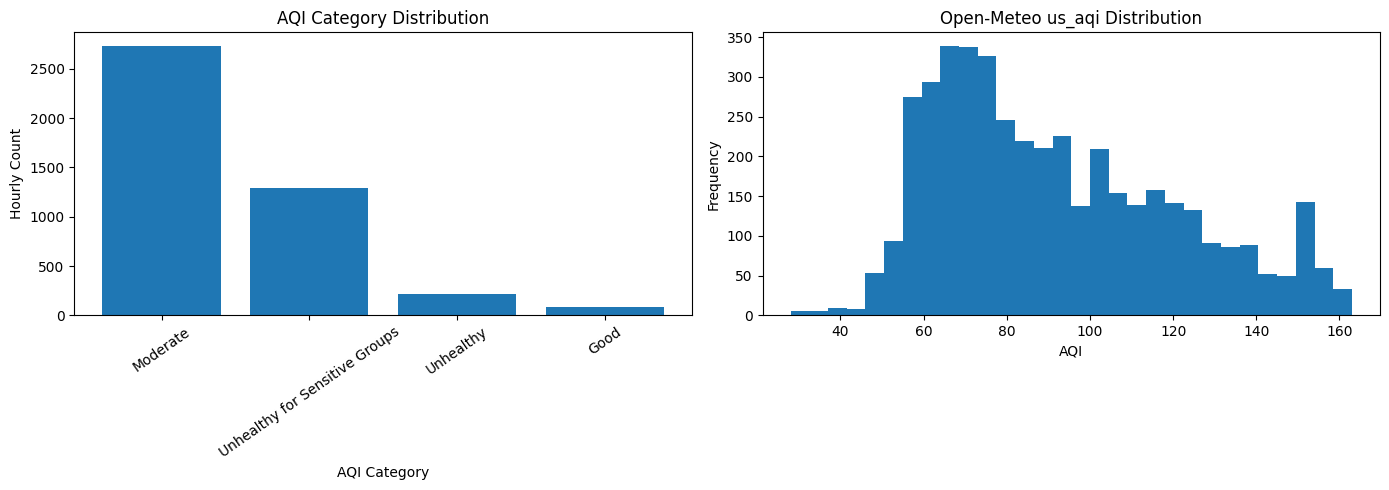

In [5]:
def aqi_category(aqi):
    if pd.isna(aqi):
        return "Unknown"
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Moderate"
    if aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    if aqi <= 200:
        return "Unhealthy"
    if aqi <= 300:
        return "Very Unhealthy"
    return "Hazardous"


df["aqi_category"] = df[TARGET_COL].apply(aqi_category)

category_df = (
    df["aqi_category"]
    .value_counts()
    .reset_index()
)

category_df.columns = ["aqi_category", "count"]
category_df["percent"] = category_df["count"] / len(df) * 100
category_df.to_csv(EDA_DIR / "aqi_category_distribution.csv", index=False)

display(category_df)

# Create 2 graphs in same grid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: AQI Category Distribution
axes[0].bar(category_df["aqi_category"], category_df["count"])
axes[0].set_title("AQI Category Distribution")
axes[0].set_xlabel("AQI Category")
axes[0].set_ylabel("Hourly Count")
axes[0].tick_params(axis="x", rotation=35)

# Graph 2: AQI Histogram
axes[1].hist(df[TARGET_COL], bins=30)
axes[1].set_title("Open-Meteo us_aqi Distribution")
axes[1].set_xlabel("AQI")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "aqi_category_and_distribution_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
top_category = category_df.iloc[0]
print(
    f"Most common AQI category is '{top_category['aqi_category']}' "
    f"with {top_category['percent']:.2f}% of the records."
)




Most common AQI category is 'Moderate' with 63.31% of the records.


## 4. Unit Conversion Validation

This section checks the converted gas features:

- `o3_8h_ppb`
- `co_8h_ppm`
- `no2_1h_ppb`

These values are derived from Open-Meteo `µg/m³` gas values.

The purpose is not to use a different target.  
The target remains Open-Meteo `us_aqi`.

The unit conversion simply creates more interpretable gas features for the model.


In [7]:
conversion_summary = df[
    [
        "ozone",
        "o3_8h",
        "o3_8h_ppb",
        "carbon_monoxide",
        "co_8h",
        "co_8h_ppm",
        "nitrogen_dioxide",
        "no2_1h",
        "no2_1h_ppb",
    ]
].describe().T

conversion_summary.to_csv(EDA_DIR / "unit_conversion_summary.csv")
display(conversion_summary)

print("Unit conversion formulas used:")
print("o3_8h_ppb  = o3_8h * (24.465 / 48)")
print("co_8h_ppm  = co_8h * (24.465 / (28 * 1000))")
print("no2_1h_ppb = no2_1h * (24.465 / 46)")


,count,mean,std,min,25%,50%,75%,max
ozone,4320.0,85.988426,34.382831,14.000000,57.000000,79.000000,116.000000,179.000000
o3_8h,4320.0,85.960322,28.297322,21.750000,62.750000,83.500000,108.000000,165.000000
o3_8h_ppb,4320.0,43.812902,14.422791,11.085703,31.982891,42.558906,55.046250,84.098437
carbon_monoxide,4320.0,589.965278,440.404458,80.000000,284.000000,457.000000,755.000000,3762.000000
co_8h,4320.0,590.726994,354.305280,150.125000,328.000000,489.500000,771.437500,3058.000000
co_8h_ppm,4320.0,0.516148,0.309574,0.131172,0.286590,0.427701,0.674044,2.671927
nitrogen_dioxide,4320.0,9.455509,8.182049,0.000000,3.400000,7.200000,12.500000,46.500000
no2_1h,4320.0,9.455509,8.182049,0.000000,3.400000,7.200000,12.500000,46.500000
no2_1h_ppb,4320.0,5.028892,4.351605,0.000000,1.808283,3.829304,6.648098,24.730924


Unit conversion formulas used:
o3_8h_ppb  = o3_8h * (24.465 / 48)
co_8h_ppm  = co_8h * (24.465 / (28 * 1000))
no2_1h_ppb = no2_1h * (24.465 / 46)



- Unit conversion is used because Open-Meteo provides gaseous pollutants in µg/m³, while gases like ozone, nitrogen dioxide, and carbon monoxide are commonly interpreted in ppb or ppm in air-quality analysis.

- Converting O3 and NO2 to ppb, and CO to ppm, makes the features more meaningful, standardized, and easier to compare with air-quality references.

- This improves feature interpretability while keeping the model target as Open-Meteo us_aqi and avoiding AQI leakage.


## 5. Why Rolling Window Features Are Used

Raw pollutant values can be noisy hour by hour.

Rolling windows help represent exposure over time:

| Feature | Window |
|---|---|
| `pm25_24h` | 24-hour PM2.5 mean |
| `pm10_24h` | 24-hour PM10 mean |
| `o3_8h_ppb` | 8-hour ozone mean converted to ppb |
| `co_8h_ppm` | 8-hour CO mean converted to ppm |
| `no2_1h_ppb` | current NO2 value converted to ppb |

This makes the features smoother and more aligned with AQI behavior.


,count,mean,std,min,25%,50%,75%,max
pm25_24h,4320.0,30.093728,13.665441,6.266667,19.264583,26.354167,38.606250,79.791667
pm10_24h,4320.0,51.521551,24.280008,12.641667,36.576042,46.560417,59.434375,220.729167
o3_8h_ppb,4320.0,43.812902,14.422791,11.085703,31.982891,42.558906,55.046250,84.098437
co_8h_ppm,4320.0,0.516148,0.309574,0.131172,0.286590,0.427701,0.674044,2.671927
no2_1h_ppb,4320.0,5.028892,4.351605,0.000000,1.808283,3.829304,6.648098,24.730924


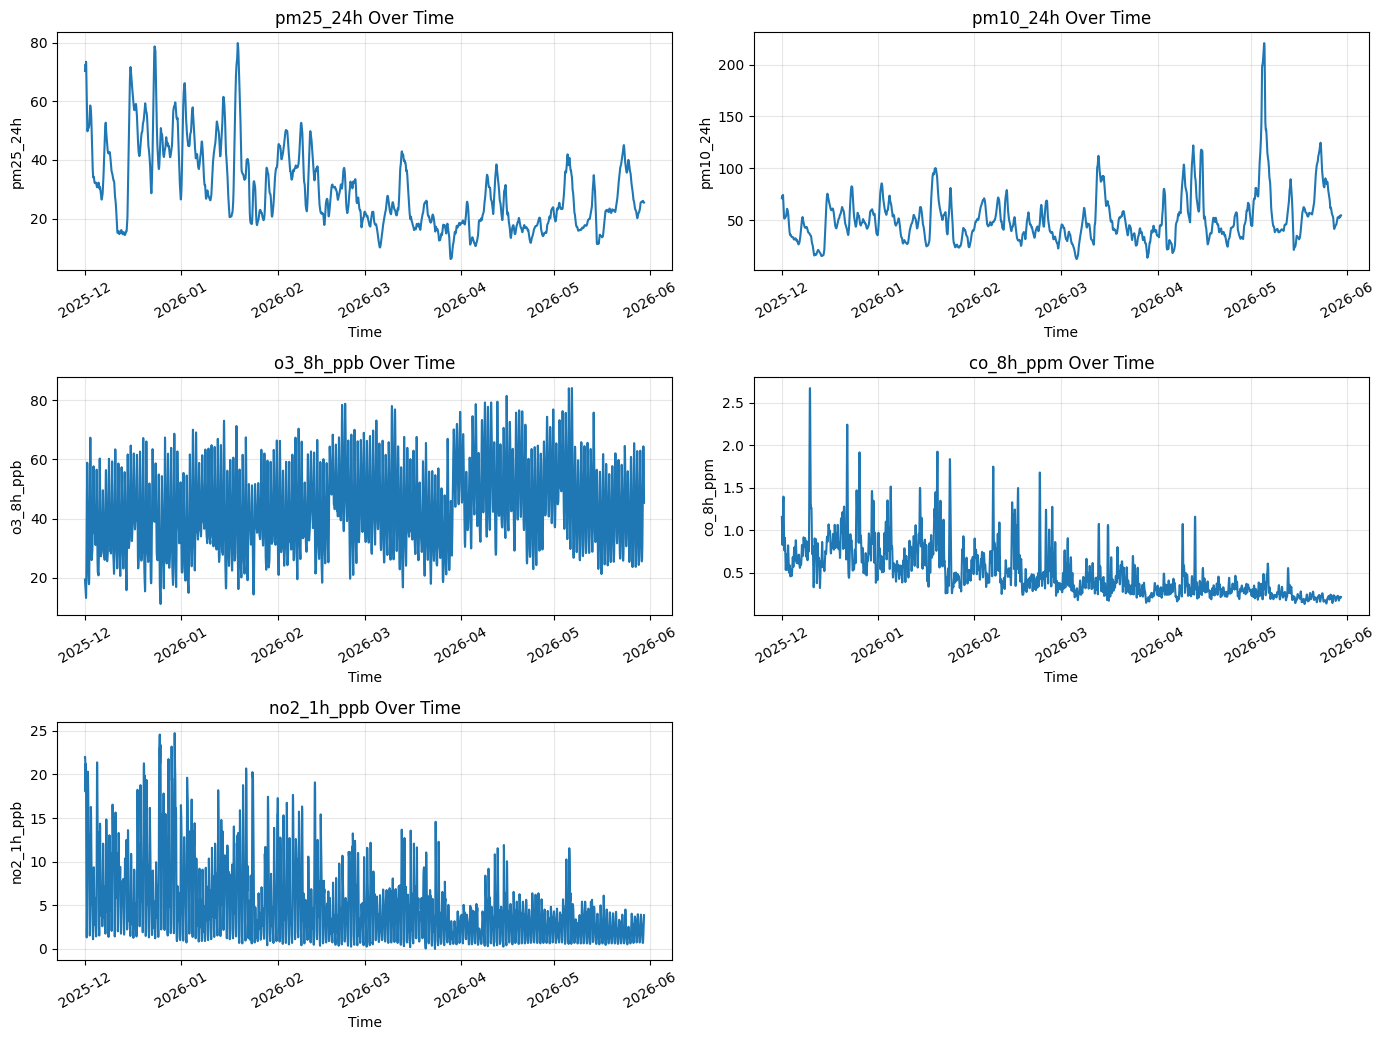

In [8]:
rolling_summary = df[DERIVED_POLLUTANT_COLS].describe().T
rolling_summary.to_csv(EDA_DIR / "rolling_feature_summary.csv")

display(rolling_summary)

# Small grid for all rolling pollutant features
n_cols = 2
n_rows = int(np.ceil(len(DERIVED_POLLUTANT_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(DERIVED_POLLUTANT_COLS):
    axes[i].plot(df["timestamp"], df[col])
    axes[i].set_title(f"{col} Over Time")
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].grid(alpha=0.3)

# Hide empty subplot if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "rolling_pollutant_features_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Correlation With Target AQI

This section checks which features are most related to `us_aqi`.

The goal is to defend why these features are selected for model training.


,feature,correlation_with_us_aqi
0,pm25_24h,0.940386
1,co_8h_ppm,0.545996
2,pm10_24h,0.464067
3,surface_pressure,0.445197
4,windspeed_10m,-0.361465
5,no2_1h_ppb,0.355010
6,temperature_2m,-0.343658
7,et0_fao_evapotranspiration,-0.196163
8,shortwave_radiation,-0.122379
9,o3_8h_ppb,0.027629


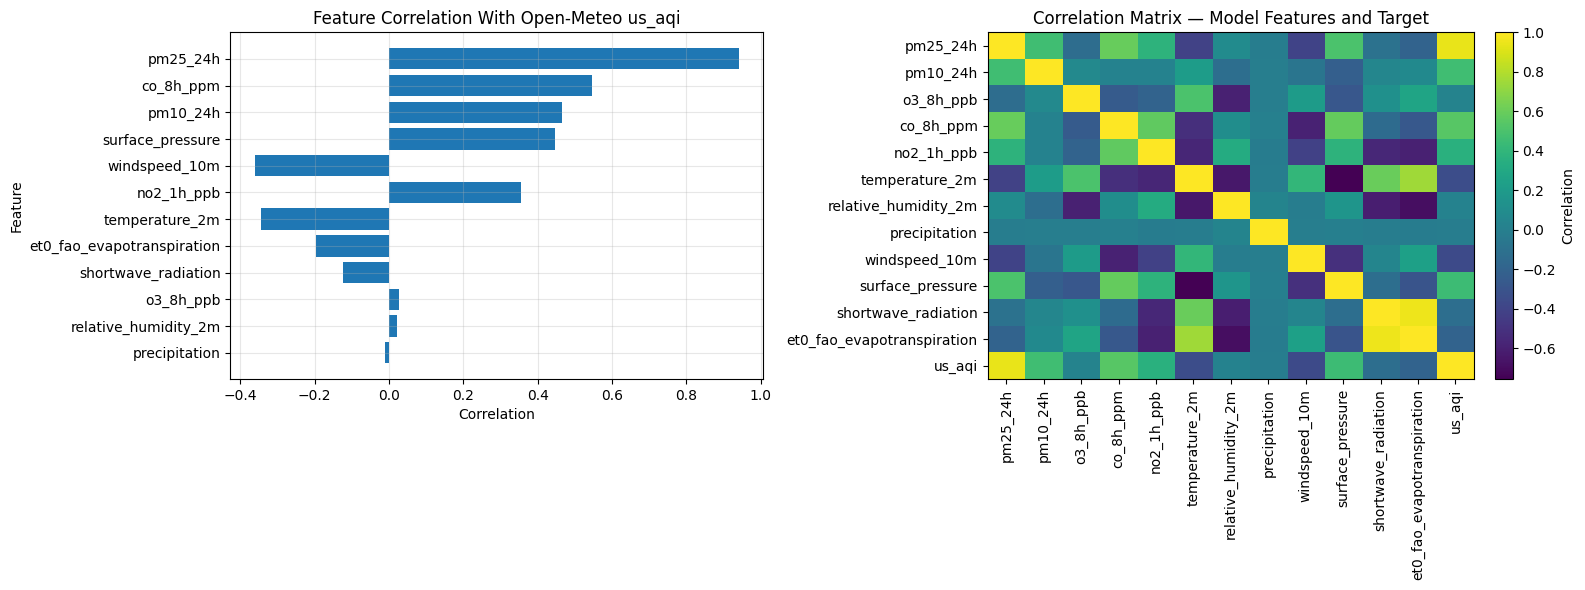

In [9]:
corr_cols = FEATURE_COLS + [TARGET_COL]
corr = df[corr_cols].corr(numeric_only=True)

target_corr = (
    corr[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
target_corr.columns = ["feature", "correlation_with_us_aqi"]
target_corr.to_csv(EDA_DIR / "feature_target_correlations.csv", index=False)

display(target_corr)

# Create 2 plots in one grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature correlation with target
axes[0].barh(target_corr["feature"], target_corr["correlation_with_us_aqi"])
axes[0].set_title("Feature Correlation With Open-Meteo us_aqi")
axes[0].set_xlabel("Correlation")
axes[0].set_ylabel("Feature")
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

# Plot 2: Correlation matrix
im = axes[1].imshow(corr, aspect="auto")
axes[1].set_title("Correlation Matrix — Model Features and Target")
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=90)
axes[1].set_yticks(range(len(corr.index)))
axes[1].set_yticklabels(corr.index)

# colorbar for matrix
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Correlation")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
top_features = target_corr.head(5)
print("Top 5 features most related to AQI:")
display(top_features)

strong_features = target_corr[target_corr["correlation_with_us_aqi"].abs() >= 0.40]



Top 5 features most related to AQI:


,feature,correlation_with_us_aqi
0,pm25_24h,0.940386
1,co_8h_ppm,0.545996
2,pm10_24h,0.464067
3,surface_pressure,0.445197
4,windspeed_10m,-0.361465


## 7. Scatter Plots — Important Features vs AQI

Scatter plots show whether pollutant-window features increase with AQI.

This helps visually defend that the selected features are useful.


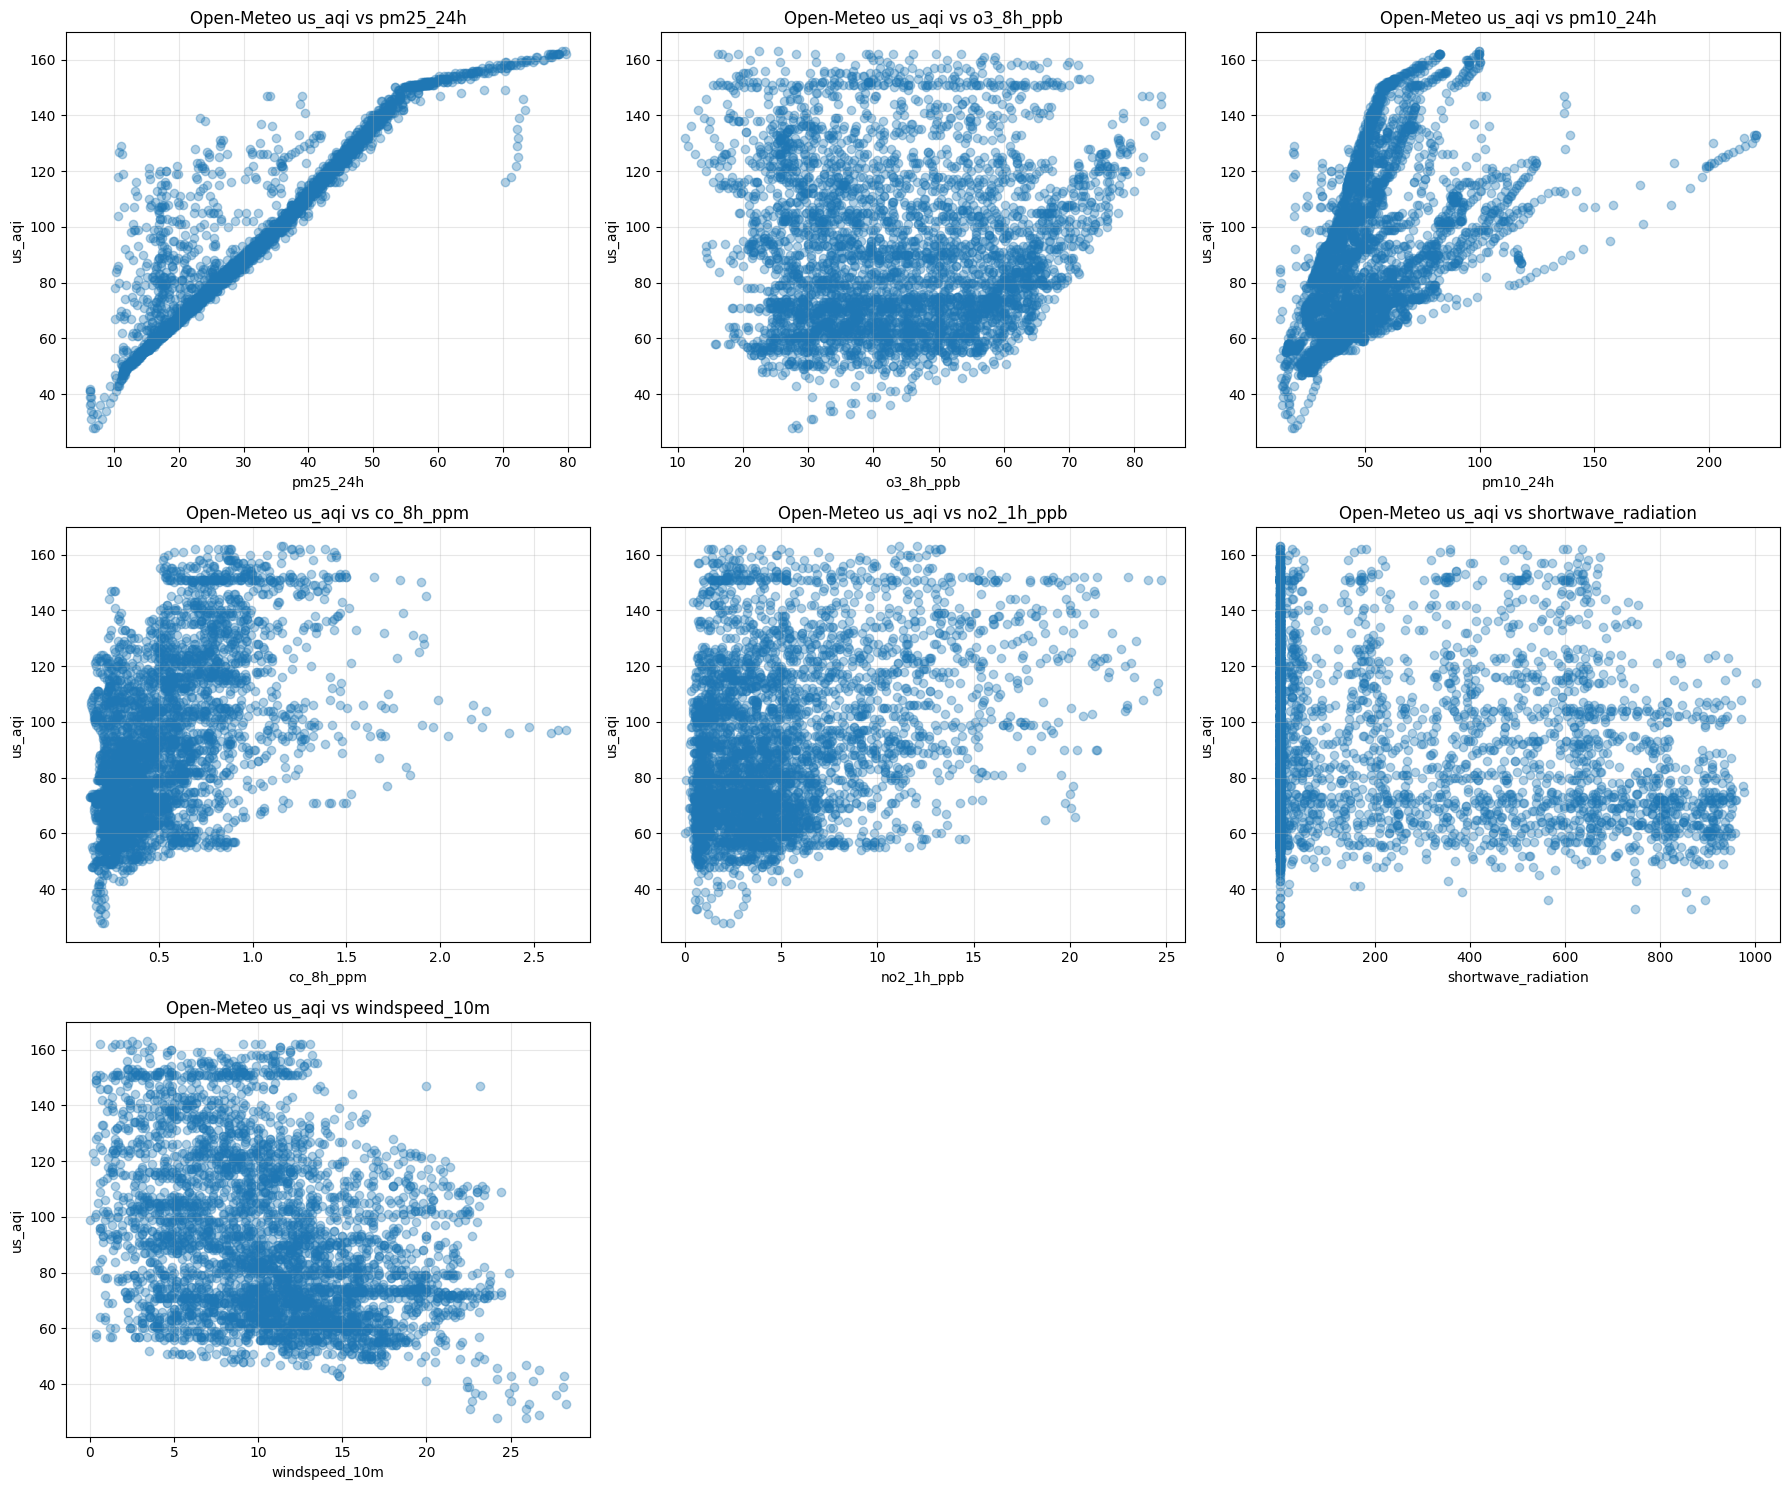

In [11]:
important_features = [
    "pm25_24h",
    "o3_8h_ppb",
    "pm10_24h",
    "co_8h_ppm",
    "no2_1h_ppb",
    "shortwave_radiation",
    "windspeed_10m",
]

important_features = [col for col in important_features if col in df.columns]

# Grid settings
n_cols = 3
n_rows = int(np.ceil(len(important_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(important_features):
    axes[i].scatter(df[col], df[TARGET_COL], alpha=0.35)
    axes[i].set_title(f"Open-Meteo us_aqi vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("us_aqi")
    axes[i].grid(alpha=0.3)

# Hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_us_aqi_feature_grid.png", dpi=150, bbox_inches="tight")
plt.show()



- The scatter plots show that `pm25_24h` has the strongest and clearest positive relationship with `us_aqi`, meaning AQI increases as PM2.5 rolling average increases. `pm10_24h` also shows a positive pattern, while ozone, CO, NO2, radiation, and wind speed show more scattered relationships. This confirms that particulate matter features, especially `pm25_24h`, are the most important predictors for the AQI model.

## 8. Daily and Hourly AQI Patterns

This checks if AQI has time-related patterns.




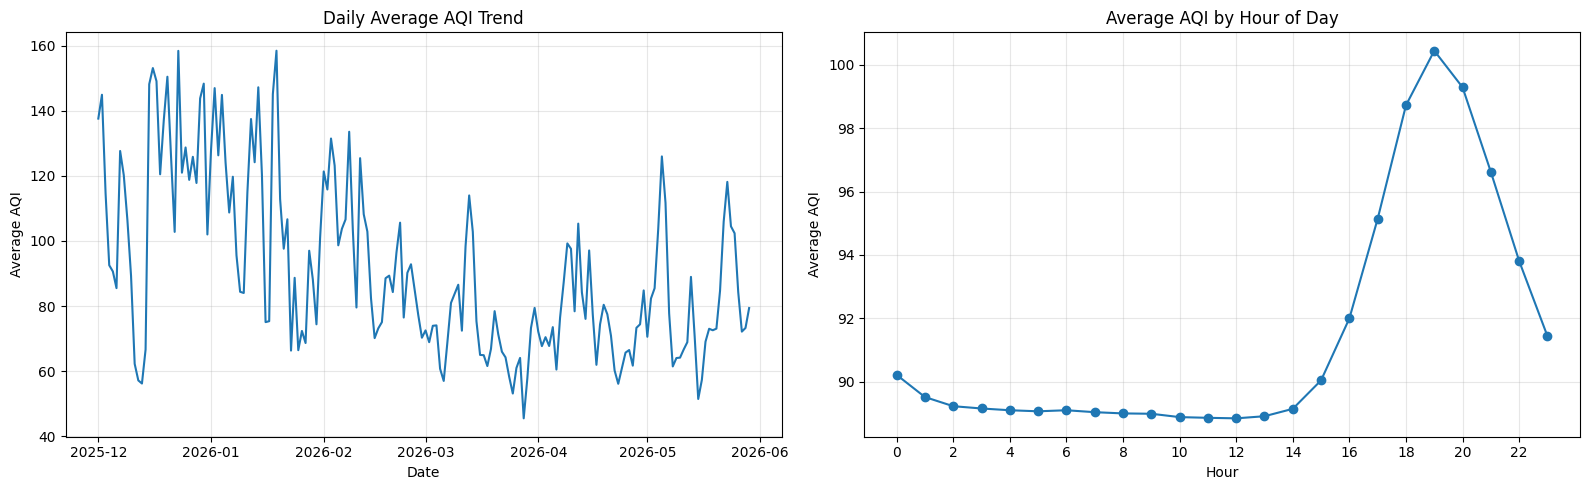

In [12]:
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

daily_aqi = (
    df.groupby("date")
    .agg(
        avg_aqi=(TARGET_COL, "mean"),
        max_aqi=(TARGET_COL, "max"),
        min_aqi=(TARGET_COL, "min"),
    )
    .reset_index()
)
daily_aqi.to_csv(EDA_DIR / "daily_aqi_summary.csv", index=False)

hourly_pattern = (
    df.groupby("hour")
    .agg(avg_aqi=(TARGET_COL, "mean"))
    .reset_index()
)
hourly_pattern.to_csv(EDA_DIR / "hourly_aqi_pattern.csv", index=False)

# Create both plots in one grid
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Daily AQI trend
axes[0].plot(pd.to_datetime(daily_aqi["date"]), daily_aqi["avg_aqi"])
axes[0].set_title("Daily Average AQI Trend")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average AQI")
axes[0].grid(alpha=0.3)

# Plot 2: Hourly AQI pattern
axes[1].plot(hourly_pattern["hour"], hourly_pattern["avg_aqi"], marker="o")
axes[1].set_title("Average AQI by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Average AQI")
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "daily_hourly_aqi_grid.png", dpi=150, bbox_inches="tight")
plt.show()



- The daily AQI trend shows noticeable fluctuations, meaning air quality changes significantly across days due to changing pollutant and weather conditions. The hourly pattern shows AQI is lower during late night and morning hours, then rises sharply in the evening, peaking around 19:00–20:00. This suggests time-based pollution behavior, likely influenced by daily activity patterns and atmospheric conditions.

## 9. Outlier Analysis

This checks whether extreme feature values exist.

Outliers matter because they can cause models like XGBoost or Random Forest to overreact.


In [13]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        count = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({
            "feature": col,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(count),
            "outlier_percent": count / len(data) * 100,
            "min": data[col].min(),
            "max": data[col].max(),
        })
    return pd.DataFrame(rows).sort_values("outlier_percent", ascending=False)

outlier_df = iqr_outlier_summary(df, FEATURE_COLS + RAW_AIR_QUALITY_COLS)
outlier_df.to_csv(EDA_DIR / "outlier_summary.csv", index=False)

display(outlier_df)


,feature,lower_bound,upper_bound,outlier_count,outlier_percent,min,max
1,pm10_24h,2.288542,93.721875,247,5.717593,12.641667,220.729167
15,nitrogen_dioxide,-10.250000,26.150000,231,5.347222,0.000000,46.500000
4,no2_1h_ppb,-5.451440,13.907821,231,5.347222,0.000000,24.730924
13,pm10,-17.900000,112.500000,194,4.490741,4.600000,560.700000
14,carbon_monoxide,-422.500000,1461.500000,189,4.375000,80.000000,3762.000000
12,pm25,-13.200000,69.200000,142,3.287037,3.500000,105.500000
3,co_8h_ppm,-0.294590,1.255224,131,3.032407,0.131172,2.671927
0,pm25_24h,-9.747917,67.618750,67,1.550926,6.266667,79.791667
11,et0_fao_evapotranspiration,-0.470000,0.890000,40,0.925926,0.000000,0.990000
7,precipitation,0.000000,0.000000,32,0.740741,0.000000,6.300000




- The outlier analysis shows that `pm10_24h`, `nitrogen_dioxide`, `pm10`, `carbon_monoxide`, and `pm25` contain the highest number of outliers, meaning pollutant levels sometimes rise sharply due to sudden air-quality events. PM10 has the largest extreme value, reaching `560.7`, which suggests occasional dust or pollution spikes.

- Most weather features such as `temperature_2m`, `relative_humidity_2m`, `surface_pressure`, `shortwave_radiation`, and `ozone` show little to no outlier problem, so they are stable for model training. Overall, the outliers are mainly in pollutant-related features, which is expected in AQI data and should be handled carefully during model training.

## 10. Feature Drift Check

This compares the first half and second half of the dataset.

If feature distributions shift a lot, the model may need regular retraining.


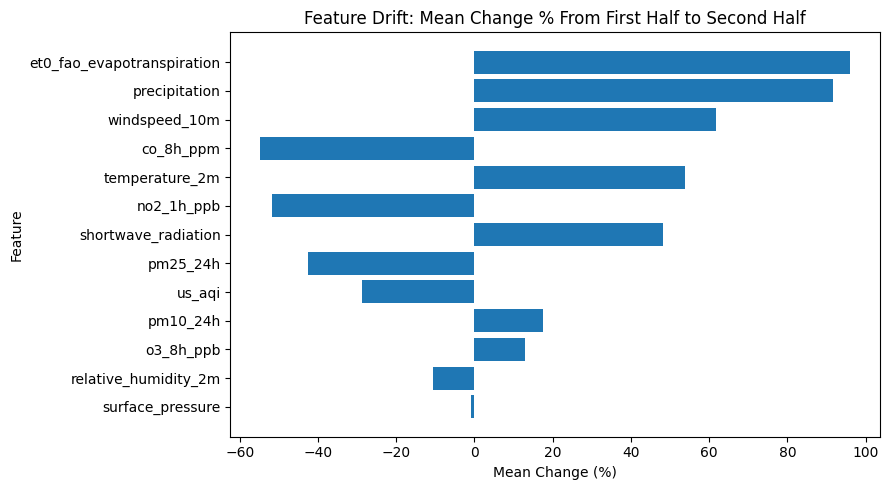

In [14]:
split_idx = len(df) // 2
first_half = df.iloc[:split_idx]
second_half = df.iloc[split_idx:]

drift_rows = []
for col in FEATURE_COLS + [TARGET_COL]:
    mean_1 = first_half[col].mean()
    mean_2 = second_half[col].mean()
    std_1 = first_half[col].std()
    std_2 = second_half[col].std()

    drift_rows.append({
        "feature": col,
        "first_half_mean": mean_1,
        "second_half_mean": mean_2,
        "mean_change": mean_2 - mean_1,
        "mean_change_percent": ((mean_2 - mean_1) / mean_1 * 100) if mean_1 != 0 else np.nan,
        "first_half_std": std_1,
        "second_half_std": std_2,
    })

drift_df = pd.DataFrame(drift_rows).sort_values("mean_change_percent", key=lambda s: s.abs(), ascending=False)
drift_df.to_csv(EDA_DIR / "feature_drift_summary.csv", index=False)



plt.figure(figsize=(9, 5))
plt.barh(drift_df["feature"], drift_df["mean_change_percent"])
plt.title("Feature Drift: Mean Change % From First Half to Second Half")
plt.xlabel("Mean Change (%)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_drift_mean_change_percent.png", dpi=150)
plt.show()


This graph shows how feature averages changed between the first half and second half of the dataset.

- The strongest positive drift appears in `et0_fao_evapotranspiration`, `precipitation`, and `windspeed_10m`, meaning these weather conditions increased strongly in the later period. Some pollutants such as `co_8h_ppm`, `no2_1h_ppb`, and `pm25_24h` decreased, which may explain why `us_aqi` also dropped by around 30%.

- Overall, the data shows noticeable drift between the two time periods, especially in weather-related features. This means the model should be retrained regularly because future data may not follow the same pattern as older training data.

In [17]:
# CELL 1: Load local 19-feature training data + local best_model.pkl

import json
import sys
import subprocess
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# Install SHAP if missing
try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

PROJECT_ROOT = Path("D:/aqi-predictor")

DATA_PATH = PROJECT_ROOT / "data" / "openmeteo_19f_training_features.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "best_model.pkl"
REPORT_DIR = PROJECT_ROOT / "reports" / "shap"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "us_aqi"

FALLBACK_FEATURE_COLUMNS = [
    "pm25_24h",
    "pm10_24h",
    "o3_8h_ppb",
    "co_8h_ppm",
    "no2_1h_ppb",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "windspeed_10m",
    "surface_pressure",
    "shortwave_radiation",
    "et0_fao_evapotranspiration",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
]

print("Data exists :", DATA_PATH.exists(), DATA_PATH)
print("Model exists:", MODEL_PATH.exists(), MODEL_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Training CSV not found: {DATA_PATH}")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

loaded_model = joblib.load(MODEL_PATH)

# Handle both formats:
# 1. plain sklearn/xgboost model
# 2. dictionary with {"model": ..., "feature_columns": ...}
if isinstance(loaded_model, dict) and "model" in loaded_model:
    model = loaded_model["model"]
    feature_columns = loaded_model.get("feature_columns", FALLBACK_FEATURE_COLUMNS)
else:
    model = loaded_model
    feature_columns = list(getattr(model, "feature_names_in_", FALLBACK_FEATURE_COLUMNS))

feature_columns = [str(col).strip().lower() for col in feature_columns]

missing_features = [col for col in feature_columns if col not in df.columns]
if missing_features:
    raise ValueError(f"Missing model features in CSV: {missing_features}")

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Target column not found: {TARGET_COLUMN}")

X = df[feature_columns].copy()
y = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")

for col in feature_columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
    median_value = X[col].median()

    if pd.isna(median_value):
        median_value = 0.0

    X[col] = X[col].fillna(median_value)

valid_mask = y.notna()
X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)

print("\n✅ Loaded successfully")
print("Data shape:", df.shape)
print("X shape:", X.shape)
print("Model type:", type(model))
print("Feature count:", len(feature_columns))
print("Target:", TARGET_COLUMN)
print("\nFeatures:")
for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:02d}. {feature}")

Data exists : True D:\aqi-predictor\data\openmeteo_19f_training_features.csv
Model exists: True D:\aqi-predictor\models\best_model.pkl

✅ Loaded successfully
Data shape: (4320, 31)
X shape: (4320, 19)
Model type: <class 'sklearn.pipeline.Pipeline'>
Feature count: 19
Target: us_aqi

Features:
01. pm25_24h
02. pm10_24h
03. o3_8h_ppb
04. co_8h_ppm
05. no2_1h_ppb
06. temperature_2m
07. relative_humidity_2m
08. precipitation
09. windspeed_10m
10. surface_pressure
11. shortwave_radiation
12. et0_fao_evapotranspiration
13. hour
14. day_of_week
15. is_weekend
16. hour_sin
17. hour_cos
18. day_of_week_sin
19. day_of_week_cos


SHAP sample size: 500
Background size: 100
Model type: pipeline
Using general SHAP Explainer...


PermutationExplainer explainer: 501it [02:23,  3.32it/s]                         


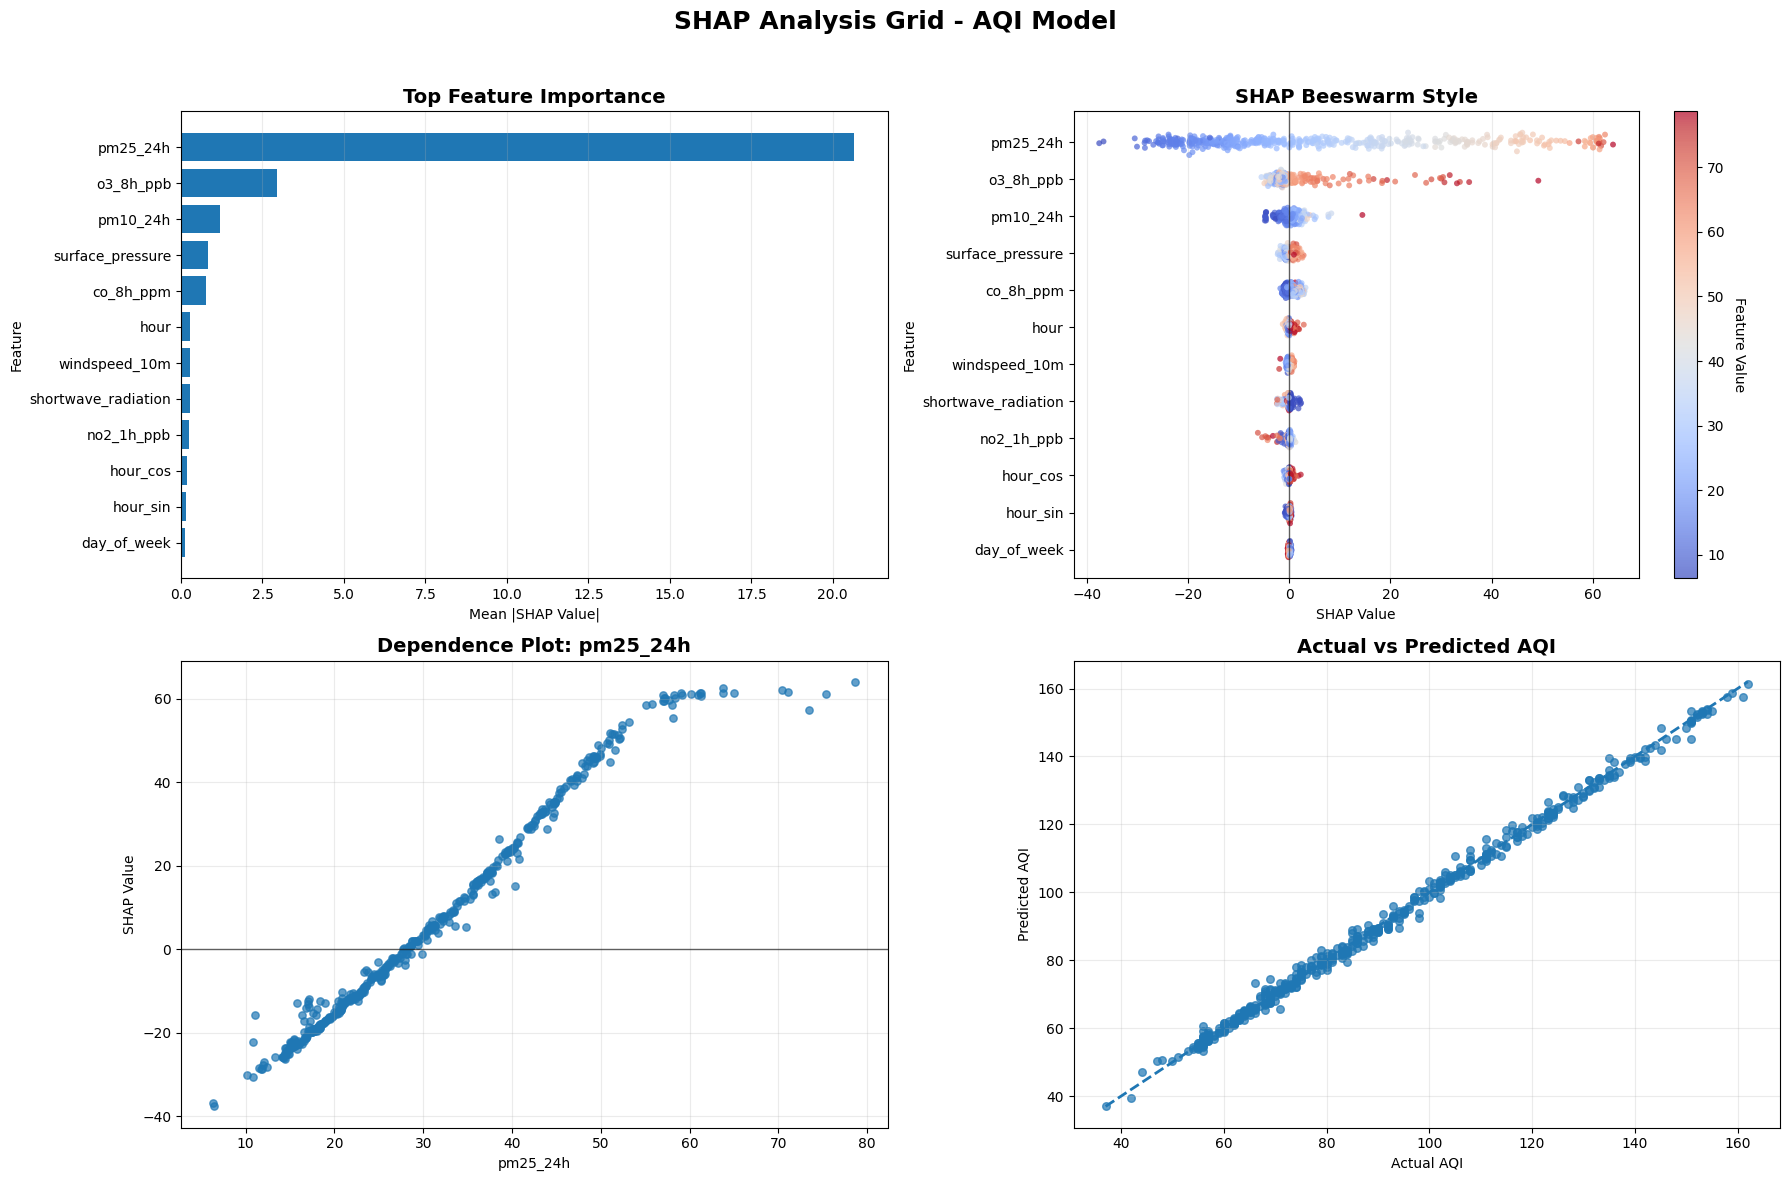


✅ SHAP outputs saved:
D:\aqi-predictor\reports\shap\shap_values.csv
D:\aqi-predictor\reports\shap\shap_feature_importance.csv
D:\aqi-predictor\reports\shap\shap_analysis_grid.png


In [19]:
# CELL 2: SHAP analysis in one grid layout

import matplotlib.pyplot as plt

REPORT_DIR = PROJECT_ROOT / "reports" / "shap"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Keep sample small so notebook does not hang
sample_size = min(500, len(X))
background_size = min(100, len(X))

X_sample = X.sample(sample_size, random_state=42)
X_background = X.sample(background_size, random_state=42)

model_type = type(model).__name__.lower()

print("SHAP sample size:", len(X_sample))
print("Background size:", len(X_background))
print("Model type:", model_type)

# Use the fastest suitable SHAP explainer
try:
    if any(name in model_type for name in ["xgb", "forest", "tree", "extra"]):
        print("Using TreeExplainer...")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_sample)

    elif any(name in model_type for name in ["ridge", "linear", "lasso"]):
        print("Using LinearExplainer...")
        explainer = shap.LinearExplainer(model, X_background)
        shap_values = explainer(X_sample)

    else:
        print("Using general SHAP Explainer...")
        explainer = shap.Explainer(model.predict, X_background)
        shap_values = explainer(X_sample)

except Exception as error:
    print("Fast explainer failed. Falling back to general Explainer.")
    print("Original error:", error)
    explainer = shap.Explainer(model.predict, X_background)
    shap_values = explainer(X_sample)

shap_array = shap_values.values

# If output is 3D for any reason, squeeze it
if len(shap_array.shape) == 3:
    shap_array = shap_array[:, :, 0]

# Save SHAP values
shap_values_df = pd.DataFrame(shap_array, columns=feature_columns)
shap_values_path = REPORT_DIR / "shap_values.csv"
shap_values_df.to_csv(shap_values_path, index=False)

# Mean absolute SHAP importance
importance_df = pd.DataFrame(
    {
        "feature": feature_columns,
        "mean_abs_shap": np.abs(shap_array).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

importance_path = REPORT_DIR / "shap_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)


# ============================================================
# Grid plots
# ============================================================

top_n = min(12, len(importance_df))
top_features = importance_df.head(top_n)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("SHAP Analysis Grid - AQI Model", fontsize=18, fontweight="bold")

# ------------------------------------------------------------
# 1. SHAP importance bar chart
# ------------------------------------------------------------

ax1 = axes[0, 0]

bar_df = importance_df.head(top_n).sort_values("mean_abs_shap", ascending=True)

ax1.barh(bar_df["feature"], bar_df["mean_abs_shap"])
ax1.set_title("Top Feature Importance", fontsize=14, fontweight="bold")
ax1.set_xlabel("Mean |SHAP Value|")
ax1.set_ylabel("Feature")
ax1.grid(axis="x", alpha=0.25)

# ------------------------------------------------------------
# 2. Custom beeswarm-style plot
# ------------------------------------------------------------

ax2 = axes[0, 1]

rng = np.random.default_rng(42)

for i, feature in enumerate(reversed(top_features)):
    feature_index = feature_columns.index(feature)

    shap_vals = shap_array[:, feature_index]
    feature_vals = pd.to_numeric(X_sample[feature], errors="coerce").fillna(0).values

    y_jitter = rng.normal(loc=i, scale=0.08, size=len(shap_vals))

    scatter = ax2.scatter(
        shap_vals,
        y_jitter,
        c=feature_vals,
        cmap="coolwarm",
        s=18,
        alpha=0.70,
        edgecolors="none",
    )

ax2.axvline(0, color="black", linewidth=1, alpha=0.6)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(list(reversed(top_features)))
ax2.set_title("SHAP Beeswarm Style", fontsize=14, fontweight="bold")
ax2.set_xlabel("SHAP Value")
ax2.set_ylabel("Feature")
ax2.grid(axis="x", alpha=0.25)

cbar = fig.colorbar(scatter, ax=ax2)
cbar.set_label("Feature Value", rotation=270, labelpad=15)

# ------------------------------------------------------------
# 3. Dependence plot for top feature
# ------------------------------------------------------------

ax3 = axes[1, 0]

top_feature = importance_df.iloc[0]["feature"]
top_feature_index = feature_columns.index(top_feature)

ax3.scatter(
    X_sample[top_feature],
    shap_array[:, top_feature_index],
    alpha=0.70,
    s=28,
)

ax3.axhline(0, color="black", linewidth=1, alpha=0.6)
ax3.set_title(f"Dependence Plot: {top_feature}", fontsize=14, fontweight="bold")
ax3.set_xlabel(top_feature)
ax3.set_ylabel("SHAP Value")
ax3.grid(alpha=0.25)

# ------------------------------------------------------------
# 4. Actual vs predicted on SHAP sample
# ------------------------------------------------------------

ax4 = axes[1, 1]

y_pred_sample = np.clip(model.predict(X_sample), 0, 500)
y_actual_sample = y.loc[X_sample.index].values

ax4.scatter(
    y_actual_sample,
    y_pred_sample,
    alpha=0.70,
    s=30,
)

min_val = min(np.min(y_actual_sample), np.min(y_pred_sample))
max_val = max(np.max(y_actual_sample), np.max(y_pred_sample))

ax4.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
)

ax4.set_title("Actual vs Predicted AQI", fontsize=14, fontweight="bold")
ax4.set_xlabel("Actual AQI")
ax4.set_ylabel("Predicted AQI")
ax4.grid(alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])

grid_path = REPORT_DIR / "shap_analysis_grid.png"
plt.savefig(grid_path, dpi=200, bbox_inches="tight")
plt.show()

print("\n✅ SHAP outputs saved:")
print(shap_values_path)
print(importance_path)
print(grid_path)